In [1]:
# This demonstrates the bias in the batch splitting algorithm that uses pytorch.randint()

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
import numpy as np
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [10]:
count = torch.zeros(Xtr.shape[0])
batch_size = 32
g = torch.Generator().manual_seed(2147483647)

print(Xtr.shape[0])
num_steps = 200000
for i in range(num_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    count[ix] += 1

182625


In [14]:
import math

# 1. Generate random indices
num_train = Xtr.shape[0]
indices = torch.randperm(Xtr.shape[0])

batch_tuples=[]
for i in range(math.ceil(num_train / batch_size)):
    low = i * batch_size
    high = ((i+1) * batch_size) 
    high = min(high, num_train)
    batch_tuples.append((low, high))

print(f"batch_tuples = {batch_tuples[:10]}")

# 2. Reorder the tensor
shuffled_x = Xtr[indices]

count_shuffle = torch.zeros(Xtr.shape[0])
for i in range(num_steps):
    batch_range = batch_tuples[ i % len(batch_tuples)]
    #print(batch_range)
    ix = torch.arange(batch_range[0], batch_range[1])
    #print(ix.shape, ix)
    ixx = indices[ix]
    count_shuffle[ix] += 1

print(count_shuffle[:100])

batch_tuples = [(0, 32), (32, 64), (64, 96), (96, 128), (128, 160), (160, 192), (192, 224), (224, 256), (256, 288), (288, 320)]
tensor([36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36.,
        36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36.,
        36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36.,
        36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36.,
        36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36.,
        36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36.,
        36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36., 36.,
        36., 36.])


avg = 35.044490075290895


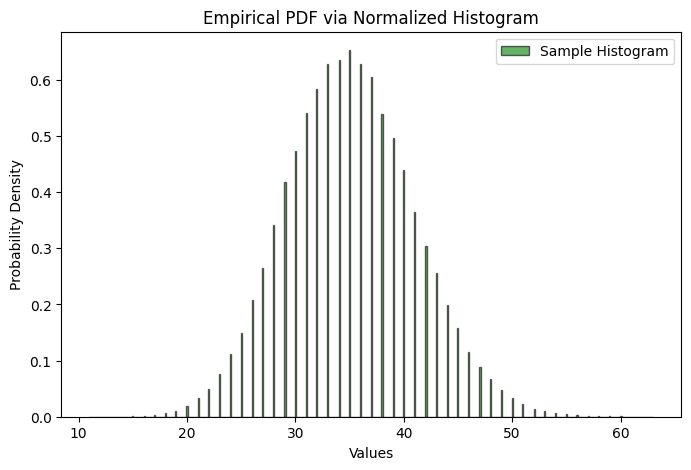

tensor([35., 37., 24., 37., 32., 26., 36., 41., 32., 37., 35., 27., 41., 38.,
        34., 45., 39., 40., 33., 37., 33., 36., 45., 31., 31., 40., 37., 26.,
        36., 36., 35., 33., 34., 32., 26., 29., 33., 27., 36., 31., 32., 22.,
        32., 30., 23., 29., 27., 35., 26., 32., 32., 35., 34., 40., 34., 43.,
        29., 29., 31., 35., 40., 43., 37., 44., 28., 35., 39., 34., 30., 32.,
        34., 37., 41., 41., 37., 40., 27., 36., 37., 38., 42., 40., 26., 47.,
        39., 43., 29., 37., 22., 34., 36., 39., 40., 44., 32., 39., 39., 36.,
        28., 40.])


In [16]:
# This PDF shows the bias that certain values occur 2x to 3x more frequently that certain others.
# The exact count should be around 35.044 for each value, for 200k steps.

print(f"avg = {num_steps * batch_size / Xtr.shape[0]}")
data = count
plt.figure(figsize=(8, 5))
plt.hist(data, bins=500, density=True, alpha=0.6, color='g', edgecolor='black', label='Sample Histogram')

plt.title('Empirical PDF via Normalized Histogram')
plt.xlabel('Values')
plt.ylabel('Probability Density')
plt.legend()
plt.show()
print(count[:100])

avg = 35.044490075290895


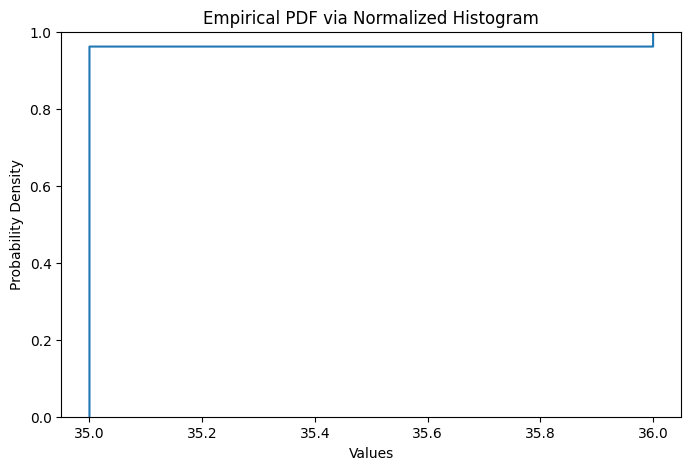

tensor([35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35.,
        35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35.,
        35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35.,
        35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35.,
        35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35.,
        35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35.,
        35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35., 35.,
        35., 35.])


In [19]:
# This shows that each value occurs the same number of times, mostly 36 or 35 times, thus eliminating the bias
# as much as possible (ofcourse 200k does not evenly divide by Xtr.shape[0], so some values are left out at 35 at
# the tail end).

print(f"avg = {num_steps * batch_size / Xtr.shape[0]}")
data = count_shuffle
plt.figure(figsize=(8, 5))
# plt.hist(data, bins=500, density=True, alpha=0.6, color='g', edgecolor='black', label='Sample Histogram')
plt.ecdf(data)
plt.title('Empirical PDF via Normalized Histogram')
plt.xlabel('Values')
plt.ylabel('Probability Density')
#plt.legend()
plt.show()
print(count_shuffle[10000:10100])